# Import Libraries

In [2]:
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pennylane as qml
from pennylane import numpy as np

# Training data Import

### Creating column names based on the readme file

In [2]:
operational_settings = ['op_setting_{}'.format(i + 1) for i in range (3)]
sensor_columns = ['sensor_{}'.format(i + 1) for i in range(27)]
features = operational_settings + sensor_columns
metadata = ['engine_no', 'time_in_cycles']
list_columns = metadata + features

 ### Importing training data and adding headers to the table

In [3]:
df = pd.read_csv('./CMAPSSData/train_FD001.txt', sep = ' ', header= None, names = list_columns)
df.head(2)

,engine_no,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388,100.0,39.06,23.4190,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388,100.0,39.00,23.4236,NaN,NaN,NaN,NaN,NaN,NaN


# Training data preprocessing

### Adding RUL column and reorganizing the df

In [4]:
df_max_life = df.groupby('engine_no')['time_in_cycles'].max().reset_index()
df_max_life.rename(columns={'time_in_cycles': 'Max Life'}, inplace=True)
df=df.merge(df_max_life, on=['engine_no'], how='left')
df['RUL'] = df['Max Life'] - df['time_in_cycles']

#col = list(raw_df.columns)
#df = raw_df[col[0:2]+[col[-1]]+col[2:32]]
df

,engine_no,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,Max Life,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,39.06,23.4190,NaN,NaN,NaN,NaN,NaN,NaN,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,39.00,23.4236,NaN,NaN,NaN,NaN,NaN,NaN,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,38.95,23.3442,NaN,NaN,NaN,NaN,NaN,NaN,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,38.88,23.3739,NaN,NaN,NaN,NaN,NaN,NaN,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,38.90,23.4044,NaN,NaN,NaN,NaN,NaN,NaN,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,38.49,22.9735,NaN,NaN,NaN,NaN,NaN,NaN,200,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,38.30,23.1594,NaN,NaN,NaN,NaN,NaN,NaN,200,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,38.44,22.9333,NaN,NaN,NaN,NaN,NaN,NaN,200,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,38.29,23.0640,NaN,NaN,NaN,NaN,NaN,NaN,200,1


### Deleting NaN and constant columns

In [5]:
for col in df.columns:
    if len(df[col].unique()) == 1:
        df.drop(col,inplace=True,axis=1)

### Saving to a new file

### Using Pearson correlation matrix choosing top 4 most correlated indicators

### Deleting irrelevant data from training set

```python 
df.drop(['op_setting_1', 'op_setting_2', 'engine_no', 'time_in_cycles'],inplace=True,axis=1)

## Normalize data

In [7]:
for col in df.columns:
    if col!='engine_no':
        df[col] =(df[col]-df[col].min())/(df[col].max() - df[col].min())

### Splitting the df into x and y

# Correlation analysis

In [8]:
pearson = df.corr(method='pearson').abs()
RUL_corr = pearson.sort_values('RUL', ascending = False)
RUL_corr['RUL']

RUL               1.000000
time_in_cycles    0.736241
sensor_11         0.696228
sensor_4          0.678948
sensor_12         0.671983
sensor_7          0.657223
sensor_15         0.642667
sensor_21         0.635662
sensor_20         0.629428
sensor_2          0.606484
sensor_17         0.606154
sensor_3          0.584520
sensor_8          0.563968
sensor_13         0.562569
sensor_9          0.390102
Max Life          0.363152
sensor_14         0.306769
sensor_6          0.128348
engine_no         0.078753
op_setting_1      0.003198
op_setting_2      0.001948
Name: RUL, dtype: float64

# Neural Network

## Creating the neural network model

In [9]:
df.shape

(20631, 21)

In [10]:
# repeatedly reduce the size
class Autoencoder_Linear(nn.Module):
    def __init__(self):
        super().__init__()        
        self.encoder = nn.Sequential(
            nn.Linear(20, 16), # (N, 784) -> (N, 128)
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 5),
            
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(5, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
            nn.ReLU(),
            nn.Linear(16, 20),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [11]:
model = Autoencoder_Linear()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3, 
                             weight_decay=1e-5)

## Transform df to tensor

In [12]:
X = torch.tensor(df[df.columns.difference(['engine_no'])].values, dtype=torch.float32)

## Train model and calculate losses

In [ ]:
num_epochs = 1000
outputs = []
loss_dict={}
for epoch in tqdm(range(num_epochs)):
    recon = model(X)
    loss = criterion(recon, X)
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_dict[epoch] = loss.item()

100%|██████████| 1000/1000 [00:15<00:00, 66.23it/s]


<Axes: xlabel='Epoch'>

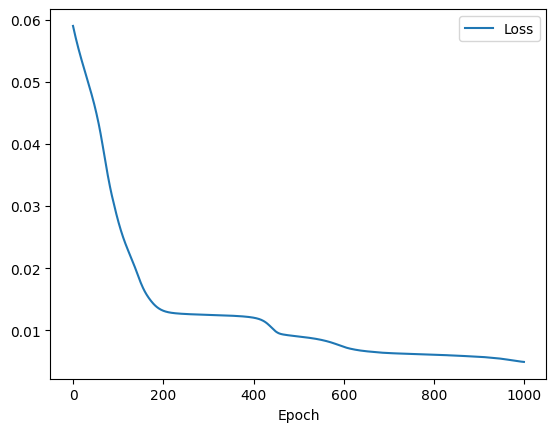

In [36]:
df_loss = pd.DataFrame.from_dict(loss_dict, orient='index', columns=['Loss'])
df_loss.index.name = 'Epoch'
df_loss.reset_index(inplace=True)
df_loss.plot(x='Epoch', y='Loss')

## Compare original and reconstructed signal

### Single row

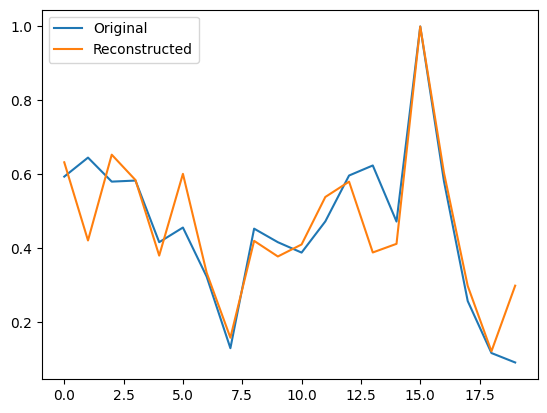

In [ ]:
i = np.random.randint(0, len(X))
original = X[i].detach().numpy()
reconstructed = model(X[i].unsqueeze(0)).detach().numpy()[0]

plt.plot(original, label='Original')
plt.plot(reconstructed, label='Reconstructed')
plt.legend()
plt.show()

### All rows

<Axes: xlabel='sensor', ylabel='delta'>

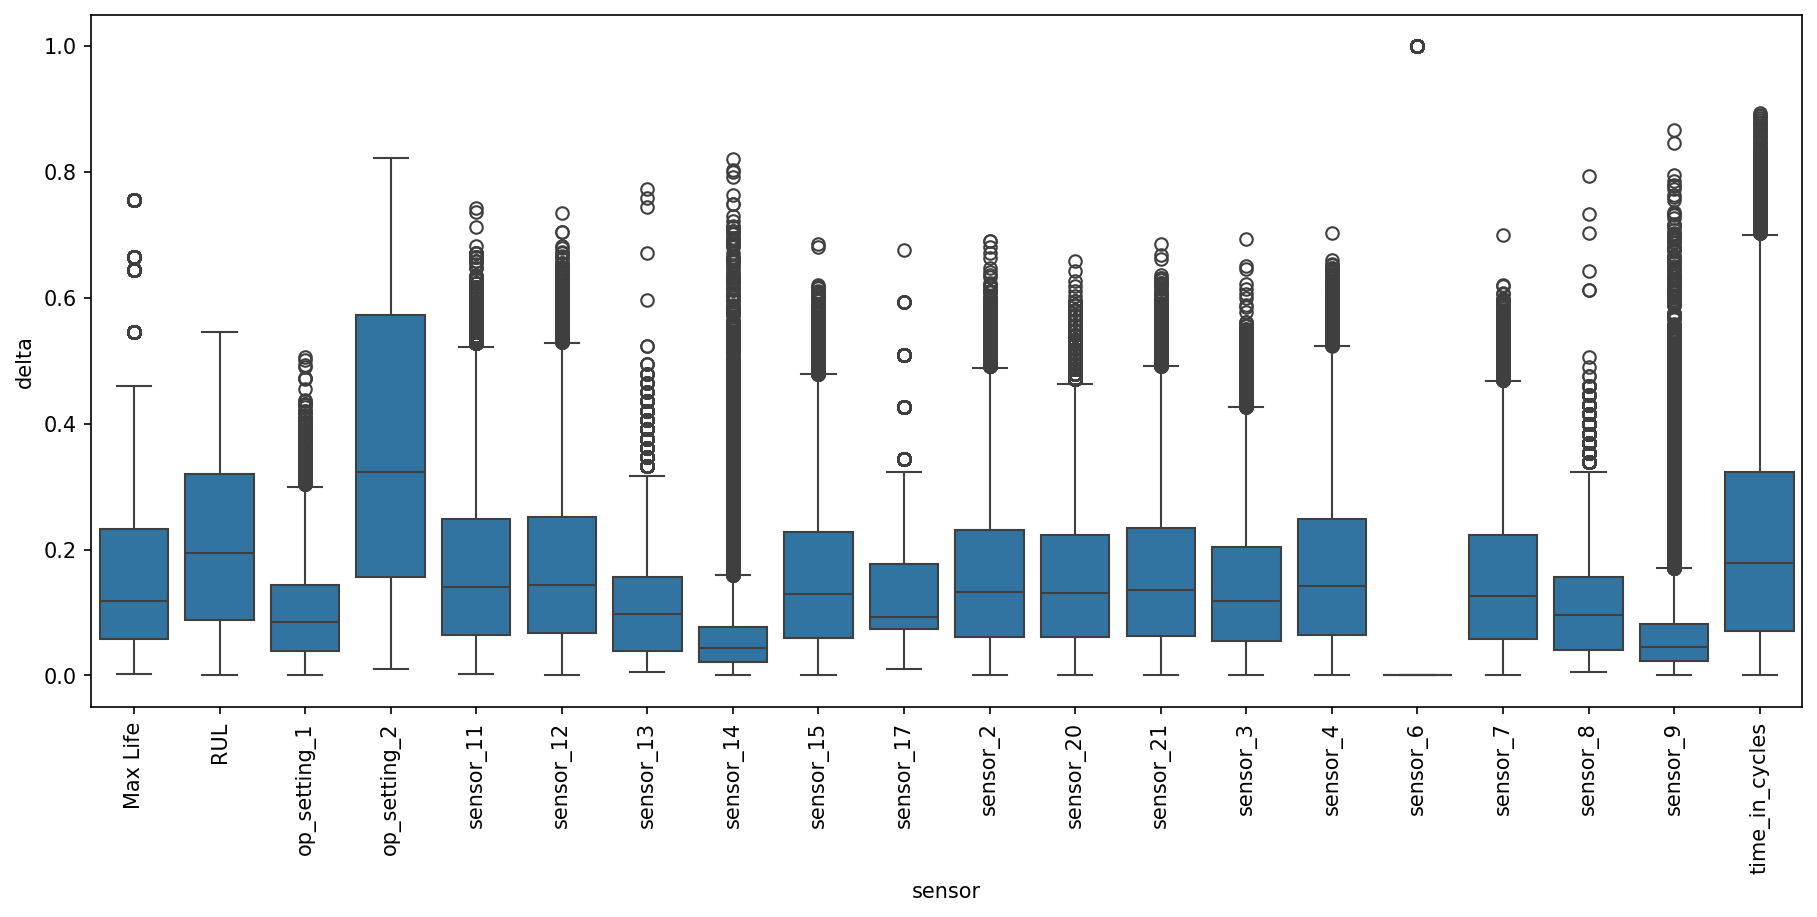

In [33]:
original = X.detach().numpy()
reconstructed = model(X).detach().numpy()[0]

delta = np.abs(original - reconstructed)
delta=pd.DataFrame(delta,columns=df.columns.difference(['engine_no']))
delta=pd.melt(delta,var_name='sensor',value_name='delta')

fig, axes = plt.subplots(figsize=(12,6),dpi=150,layout='constrained')
axes.xaxis.set_tick_params(rotation=90)
sns.boxplot(x='sensor', y='delta', data=delta)

In [34]:
delta.describe()

,delta
count,412620.000000
mean,0.150061
std,0.143934
min,0.000003
25%,0.040968
50%,0.105549
75%,0.216740
max,0.999767


## Errors

In [37]:
with torch.no_grad():
    recon = model(X)
    mse = torch.mean((recon - X) ** 2).item()
    mae = torch.mean(torch.abs(recon - X)).item()

print(f"Średni MSE: {mse:.6f}")
print(f"Średni MAE: {mae:.6f}")

Średni MSE: 0.004875
Średni MAE: 0.052072


# QML

In [3]:
n_qubits = 4

dev = qml.device("lightning.qubit", wires=n_qubits)

In [4]:
@qml.qnode(dev)
def quantum_circuit(inputs, weights,n_qubits):
    if len(inputs) != n_qubits:
        raise ValueError(f"Length of inputs must be {n_qubits}")
    # inputs: wektor 4 cech [0,1]
    # weights: parametry trenowane przez optymalizator

    # 1️⃣ Kodowanie danych w stanach kubitów (angle encoding)
    for i in range(n_qubits):
        qml.RY(np.pi * inputs[i], wires=i)

    # 2️⃣ Prosty obwód entanglujący
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])

    # 3️⃣ Parametryczne rotacje (część ucząca się)
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)

    # 4️⃣ Pomiar w bazie Z (odczyt amplitud)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [6]:
# losowe dane wejściowe i wagi
x = np.random.rand(n_qubits)
w = np.random.rand(n_qubits)

result = quantum_circuit(x, w, n_qubits=n_qubits)
print("Wynik pomiaru:", result)


Wynik pomiaru: [array(-0.97203557), array(-0.95845641), array(0.60911873), array(-0.71421958)]
